#  SmartThings Intelligent Device Prediction
## Two-Level Architecture — Full Training Pipeline (10 Epochs)

**Architecture:**
```
SmartThings Cloud → Data Ingestion → Heuristic Scorer → XGBoost + LSTM → Hybrid Fusion → Top Predictions
```

**Dataset:** Samsung SmartSense (snudatalab/SmartSense)  


---

## 1. Setup & Imports

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.path.abspath(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from Two_level_Arch.src.config import (
    DATA_DIR, MODEL_SAVE_DIR, DEFAULT_COUNTRY,
    HEURISTIC_W1, HEURISTIC_W2, HEURISTIC_W3,
    XGB_PARAMS, LSTM_INPUT_SIZE, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS,
    LSTM_DROPOUT, LSTM_BIDIRECTIONAL, LSTM_LR, LSTM_WEIGHT_DECAY,
    LSTM_BATCH_SIZE, LSTM_PATIENCE,
    FUSION_WEIGHTS, TOP_K, DEVICE, RANDOM_SEED, EVAL_K_VALUES,
)
from Two_level_Arch.src.data_loader import (
    download_smartsense, load_country_data, load_dictionary,
    load_routines, instances_to_dataframe,
)
from Two_level_Arch.src.feature_engineering import (
    extract_heuristic_features, extract_xgboost_features,
    extract_lstm_sequences, get_num_devices, get_num_device_controls,
)
from Two_level_Arch.src.dataset import get_dataloaders_from_splits
from Two_level_Arch.src.evaluation import evaluate_all, print_results
from Two_level_Arch.models.heuristic import HeuristicScorer
from Two_level_Arch.models.xgboost_model import ContextualReRanker
from Two_level_Arch.models.lstm_model import RoutinePredictor, train_model
from Two_level_Arch.models.hybrid_fuser import HybridDecisionEngine

# Config
NUM_EPOCHS = 10

# Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Epochs: {NUM_EPOCHS}")

Device: cpu
PyTorch: 2.10.0+cpu
Epochs: 10


## 2. Download & Load SmartSense Dataset

In [2]:
download_smartsense(DATA_DIR)

[INFO] Downloading SmartSense data from https://github.com/snudatalab/SmartSense/raw/main/data.zip ...
[INFO] Downloaded to C:\Users\Predator\OneDrive\Desktop\DND\Prism\VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem\Two_level_Arch\data\data.zip
[INFO] Extracting C:\Users\Predator\OneDrive\Desktop\DND\Prism\VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem\Two_level_Arch\data\data.zip ...
[INFO] Extracted to C:\Users\Predator\OneDrive\Desktop\DND\Prism\VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem\Two_level_Arch\data


'C:\\Users\\Predator\\OneDrive\\Desktop\\DND\\Prism\\VIT_25ST07VIT_On-Device_Predictive_Model_Integration_for_SmartThings_Ecosystem\\Two_level_Arch\\data'

In [3]:
COUNTRY = DEFAULT_COUNTRY
data_splits = load_country_data(COUNTRY, DATA_DIR)

train_data = data_splits['train']
val_data = data_splits['val']
test_data = data_splits['test']

print(f"\nCountry: {COUNTRY}")
print(f"Train: {train_data.shape}")
print(f"Val:   {val_data.shape}")
print(f"Test:  {test_data.shape}")

[INFO] Loaded train: (199786, 10, 5)
[INFO] Loaded val: (28541, 10, 5)
[INFO] Loaded test: (57082, 10, 5)

Country: kr
Train: (199786, 10, 5)
Val:   (28541, 10, 5)
Test:  (57082, 10, 5)


In [7]:
dictionary = load_dictionary(COUNTRY, DATA_DIR)
if dictionary:
    for key, mapping in dictionary.items():
        print(f"  {key}: {len(mapping)} entries")

routines = load_routines(COUNTRY, DATA_DIR)

all_data = np.concatenate([train_data, val_data, test_data], axis=0)
NUM_DEVICES = get_num_devices(all_data)
NUM_DEVICE_CONTROLS = get_num_device_controls(all_data)

print(f"\nUnique devices: {NUM_DEVICES}")
print(f"Unique device_controls: {NUM_DEVICE_CONTROLS}")

[INFO] Loaded dictionary for 'kr': ['dayofweek_dict', 'hour_dict', 'device_dict', 'device_control_dict']
  dayofweek_dict: 7 entries
  hour_dict: 8 entries
  device_dict: 38 entries
  device_control_dict: 272 entries
[INFO] Loaded 4891 routines for 'kr'

Unique devices: 38
Unique device_controls: 268


## 3. Data Exploration

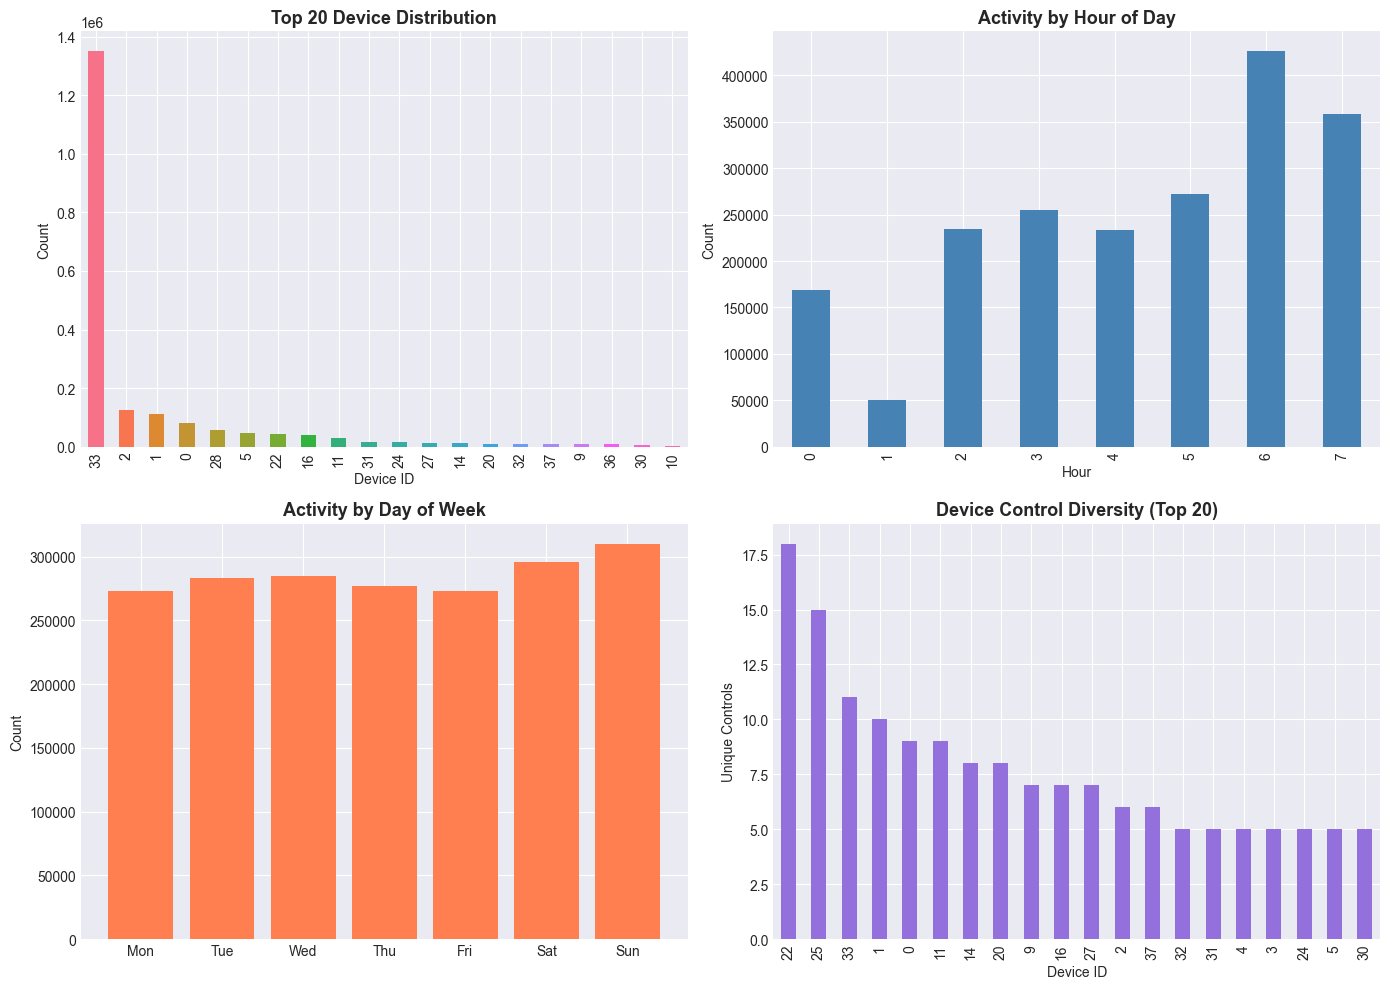

In [6]:
train_df = instances_to_dataframe(train_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
device_counts = train_df['device'].value_counts().head(20)
device_counts.plot(kind='bar', ax=ax, color=sns.color_palette('husl', 20))
ax.set_title('Top 20 Device Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Device ID'); ax.set_ylabel('Count')

ax = axes[0, 1]
train_df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Activity by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Count')

ax = axes[1, 0]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = train_df['day_of_week'].value_counts().sort_index()
ax.bar(range(len(day_counts)), day_counts.values, color='coral')
ax.set_xticks(range(len(day_counts)))
ax.set_xticklabels(day_names[:len(day_counts)])
ax.set_title('Activity by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1, 1]
dc_per_device = train_df.groupby('device')['device_control'].nunique().sort_values(ascending=False).head(20)
dc_per_device.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Device Control Diversity (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Device ID'); ax.set_ylabel('Unique Controls')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
# 4.1 Heuristic Features
print("Extracting heuristic features...")
train_heuristic = extract_heuristic_features(train_data, NUM_DEVICES)
val_heuristic = extract_heuristic_features(val_data, NUM_DEVICES)
test_heuristic = extract_heuristic_features(test_data, NUM_DEVICES)
print(f"  Recency: {train_heuristic['recency'].shape}  |  Frequency: {train_heuristic['frequency'].shape}  |  Power: {train_heuristic['power'].shape}")

# 4.2 XGBoost Tabular Features
print("\nExtracting XGBoost features...")
X_train_xgb, y_train_xgb, groups_train = extract_xgboost_features(train_data, NUM_DEVICES)
X_val_xgb, y_val_xgb, groups_val = extract_xgboost_features(val_data, NUM_DEVICES)
X_test_xgb, y_test_xgb, groups_test = extract_xgboost_features(test_data, NUM_DEVICES)
print(f"  X_train: {X_train_xgb.shape}  |  Features: {X_train_xgb.shape[1]}")

# 4.3 LSTM Sequential Features
print("\nExtracting LSTM sequences...")
X_train_lstm, y_train_lstm = extract_lstm_sequences(train_data, normalize=True)
X_val_lstm, y_val_lstm = extract_lstm_sequences(val_data, normalize=True)
X_test_lstm, y_test_lstm = extract_lstm_sequences(test_data, normalize=True)
print(f"  X_train: {X_train_lstm.shape} → y_train: {y_train_lstm.shape}")
print(f"  Unique target devices: {len(np.unique(y_train_lstm))}")

Extracting heuristic features...
  Recency: (199786, 38)  |  Frequency: (199786, 38)  |  Power: (199786, 38)

Extracting XGBoost features...
  X_train: (7591868, 11)  |  Features: 11

Extracting LSTM sequences...
  X_train: (199786, 9, 5) → y_train: (199786,)
  Unique target devices: 27


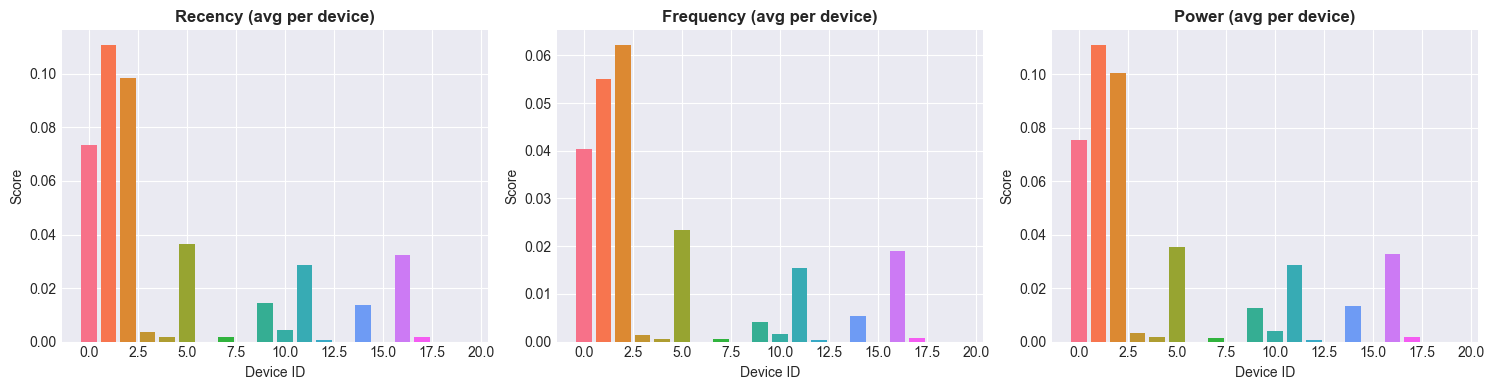

In [9]:
# Feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, feat) in enumerate(train_heuristic.items()):
    ax = axes[idx]
    mean_feat = feat.mean(axis=0)
    ax.bar(range(min(20, NUM_DEVICES)), mean_feat[:20], color=sns.color_palette('husl', 20))
    ax.set_title(f'{name.capitalize()} (avg per device)', fontweight='bold')
    ax.set_xlabel('Device ID'); ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 5. Level 1 — Heuristic Scorer

$\text{Score} = w_1 \cdot \text{Recency} + w_2 \cdot \text{Frequency} + w_3 \cdot \text{Power}$

In [ ]:
heuristic = HeuristicScorer(w1=HEURISTIC_W1, w2=HEURISTIC_W2, w3=HEURISTIC_W3)
print(heuristic)

heuristic_scores_train = heuristic.rank_batch(
    train_heuristic['recency'], train_heuristic['frequency'], train_heuristic['power'])
heuristic_scores_val = heuristic.rank_batch(
    val_heuristic['recency'], val_heuristic['frequency'], val_heuristic['power'])
heuristic_scores_test = heuristic.rank_batch(
    test_heuristic['recency'], test_heuristic['frequency'], test_heuristic['power'])

test_targets = test_data[:, -1, 2].astype(int)

heuristic_results = evaluate_all(heuristic_scores_test, test_targets, k_values=EVAL_K_VALUES)
print("\n HEURISTIC BASELINE:")
print_results(heuristic_results)

HeuristicScorer(w1=0.40, w2=0.40, w3=0.20)
  Score = 0.4·Recency + 0.4·Frequency + 0.2·Power


## 6. Level 2A — XGBoost Contextual Re-Ranker (Training)

In [ ]:
xgb_reranker = ContextualReRanker(params=XGB_PARAMS)

print("Training XGBoost Re-Ranker...")
xgb_reranker.train(
    X_train_xgb, y_train_xgb, groups_train,
    X_val_xgb, y_val_xgb, groups_val
)

xgb_scores_test = xgb_reranker.predict_batch(X_test_xgb, NUM_DEVICES)

xgb_results = evaluate_all(xgb_scores_test, test_targets, k_values=EVAL_K_VALUES)
print("\n XGBoost RE-RANKER:")
print_results(xgb_results)

In [ ]:
# XGBoost Feature Importance
importance = xgb_reranker.get_feature_importance()
if importance:
    feat_names = ['recency', 'frequency', 'power', 'avg_hour',
                  'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']
    imp_vals = list(importance.values())[:len(feat_names)]
    plt.figure(figsize=(10, 5))
    plt.bar(feat_names, imp_vals, color=sns.color_palette('husl', len(feat_names)))
    plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()

## 7. Level 2B — LSTM Routine Predictor (Training — 10 Epochs)

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders_from_splits(
    X_train_lstm, y_train_lstm,
    X_val_lstm, y_val_lstm,
    X_test_lstm, y_test_lstm,
    batch_size=LSTM_BATCH_SIZE,
)

lstm_model = RoutinePredictor(
    input_size=LSTM_INPUT_SIZE,
    hidden_size=LSTM_HIDDEN_SIZE,
    num_layers=LSTM_NUM_LAYERS,
    num_devices=NUM_DEVICES,
    dropout=LSTM_DROPOUT,
    bidirectional=LSTM_BIDIRECTIONAL,
).to(DEVICE)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=LSTM_WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM Parameters: {total_params:,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

In [ ]:
history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=LSTM_PATIENCE,
)

In [ ]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'o-', label='Train Loss', linewidth=2, markersize=6)
ax.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 's-', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'D-', label='Val Accuracy', linewidth=2, color='green', markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# LSTM Evaluation
lstm_probs_test = lstm_model.predict_numpy(X_test_lstm, device=DEVICE)

lstm_results = evaluate_all(lstm_probs_test, test_targets, k_values=EVAL_K_VALUES)
print("\n LSTM ROUTINE PREDICTOR:")
print_results(lstm_results)

## 8. Hybrid Decision Engine — Fusion & Ranking

In [ ]:
hybrid = HybridDecisionEngine(weights=FUSION_WEIGHTS)
print(hybrid)

ranked_devices, fused_scores = hybrid.predict(
    heuristic_scores=heuristic_scores_test,
    xgboost_scores=xgb_scores_test,
    lstm_scores=lstm_probs_test,
    top_k=TOP_K,
)

hybrid_results = evaluate_all(fused_scores, test_targets, k_values=EVAL_K_VALUES)
print("\n HYBRID DECISION ENGINE (FINAL):")
print_results(hybrid_results)

## 9. Model Comparison — All Results

In [ ]:
results_comparison = pd.DataFrame({
    'Metric': list(heuristic_results.keys()),
    'Heuristic': [f"{v:.4f}" for v in heuristic_results.values()],
    'XGBoost': [f"{v:.4f}" for v in xgb_results.values()],
    'LSTM': [f"{v:.4f}" for v in lstm_results.values()],
    'Hybrid (Final)': [f"{v:.4f}" for v in hybrid_results.values()],
})

print("\n" + "="*75)
print("   COMPLETE MODEL COMPARISON — Two-Level Architecture")
print("="*75)
print(results_comparison.to_string(index=False))
print("="*75)

In [ ]:
# Visual comparison
metrics = list(heuristic_results.keys())
h_vals = list(heuristic_results.values())
x_vals = list(xgb_results.values())
l_vals = list(lstm_results.values())
hy_vals = list(hybrid_results.values())

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - 1.5*width, h_vals, width, label='Heuristic', color='steelblue', alpha=0.85)
bars2 = ax.bar(x - 0.5*width, x_vals, width, label='XGBoost', color='coral', alpha=0.85)
bars3 = ax.bar(x + 0.5*width, l_vals, width, label='LSTM', color='mediumpurple', alpha=0.85)
bars4 = ax.bar(x + 1.5*width, hy_vals, width, label='Hybrid (Final)', color='gold', alpha=0.85, edgecolor='darkorange', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Two-Level Architecture — Model Comparison', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. LSTM Training History (Per-Epoch Data)

In [ ]:
epoch_df = pd.DataFrame({
    'Epoch': range(1, len(history['train_loss'])+1),
    'Train Loss': [f"{v:.4f}" for v in history['train_loss']],
    'Val Loss': [f"{v:.4f}" for v in history['val_loss']],
    'Val Accuracy': [f"{v:.4f}" for v in history['val_acc']],
})

print("\n" + "="*55)
print("   LSTM TRAINING HISTORY (10 EPOCHS)")
print("="*55)
print(epoch_df.to_string(index=False))
print("="*55)

## 11. Sample Predictions — Top Predictions Display

In [ ]:
print("\n" + "="*60)
print("  📱 TOP PREDICTIONS — Hybrid Decision Engine")
print("="*60)

for sample_idx in range(min(5, len(test_data))):
    scores = fused_scores[sample_idx]
    top_devices = np.argsort(scores)[::-1][:TOP_K]
    true_device = test_targets[sample_idx]

    print(f"\n  Instance {sample_idx} | True next device: {true_device}")
    print(f"  {'Rank':<6} {'Device':<12} {'Score':<10} {'Match'}")
    print(f"  {'─'*40}")
    for rank, dev_id in enumerate(top_devices, 1):
        match = "done" if dev_id == true_device else ""
        print(f"  {rank:<6} device_{dev_id:<6} {scores[dev_id]:<10.4f} {match}")

## 12. Save Trained Models

In [ ]:
xgb_reranker.save_model()
lstm_model.save_model()
print(f"\n All models saved to {MODEL_SAVE_DIR}")